# Datos y análisis exploratorio

TFM de predicción de ventas de Corporación Favorita. Trabajo con una fila por fecha, tienda y familia. Las figuras y tablas siguientes salen del histórico real utilizado en la ejecución, no de datos de ejemplo.

El cálculo reproducible está en `scripts/eda.py`. Para regenerar las tablas: `python scripts/eda.py`. Primero hay que descargar los CSV con `scripts/download_data.py`.

In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
from IPython.display import display, Image
root = Path.cwd()
if not (root / "outputs").exists():
    root = root.parent


In [2]:
summary = json.loads((root / "outputs/eda/summary.json").read_text())
display(pd.Series({k:summary[k] for k in ["rows", "stores", "families", "series", "start", "end", "observed_dates", "zero_share", "duplicate_keys", "negative_sales"]}))
print("Fechas sin observaciones:", summary["missing_dates"])

Fechas sin observaciones: ['2013-12-25', '2014-12-25', '2015-12-25', '2016-12-25']


rows                 3000888
stores                    54
families                  33
series                  1782
start             2013-01-01
end               2017-08-15
observed_dates          1684
zero_share          0.312951
duplicate_keys             0
negative_sales             0
dtype: object

## Calidad del dato

La ausencia de duplicados no basta para modelar. Faltan cuatro fechas completas, todas el 25 de diciembre. Para los lags he mantenido el calendario completo y ventas desconocidas en esas fechas. No las he convertido en ventas cero.

Las transacciones y el precio del petróleo no entran como variables del mismo día del forecast. No estarían disponibles al generar una previsión.

In [3]:
quality = pd.read_csv(root / "outputs/eda/quality.csv")
display(quality.loc[quality["nulls"].gt(0)])
display(pd.read_json(root / "data/input_checksums.json")[["file", "bytes"]])

,file,column,rows,nulls
20,oil,dcoilwtico,1218,43


,file,bytes
0,train.csv,121800373
1,test.csv,1022269
2,stores.csv,1387
3,transactions.csv,1552637
4,holidays_events.csv,22309
5,oil.csv,20580
6,sample_submission.csv,342153


## Patrón temporal

El patrón semanal justifica comparar el modelo con la venta de la semana anterior. La serie mensual muestra la evolución descriptiva del campo sales. No utilizo el EDA del histórico completo para seleccionar hiperparámetros con el test interno.

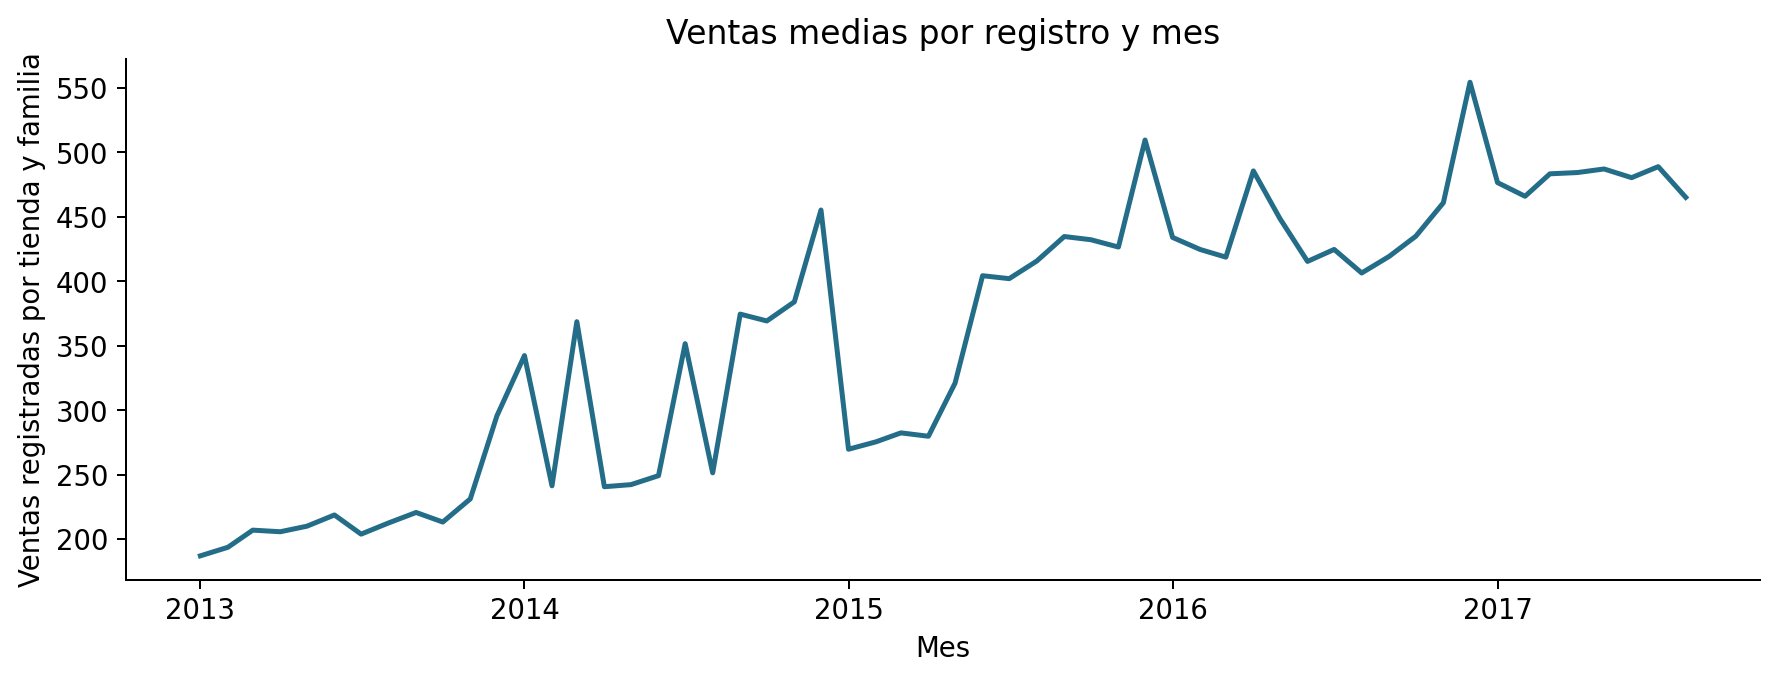

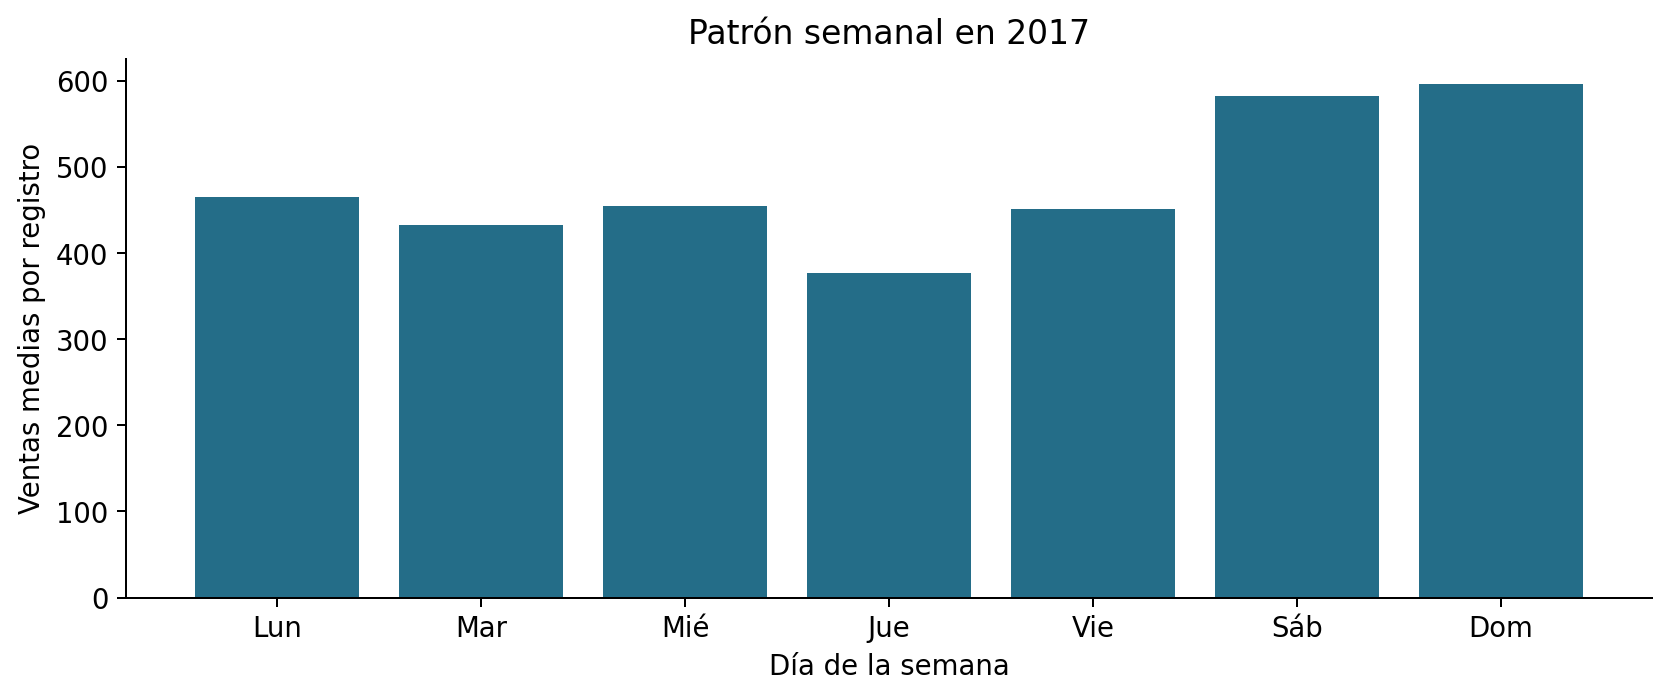

In [4]:
display(Image(filename=str(root / "docs/figures/01_monthly_sales.png")))
display(Image(filename=str(root / "docs/figures/02_weekday.png")))

## Familias y ceros

Las familias tienen escalas diferentes y muchas observaciones cero. Un buen MAE global puede ocultar problemas de algunas familias. Tampoco puedo saber si un cero corresponde a poca venta, un cierre o una rotura de stock.

,family,n,total_sales,mean_sales,median_sales,max_sales,zero_share,promotion_share
0,GROCERY I,90936,343462720.0,3776.972,3185.000,124717.000,0.081,0.626
1,BEVERAGES,90936,216954480.0,2385.793,1784.000,25413.000,0.081,0.569
2,PRODUCE,90936,122704690.0,1349.352,398.290,17850.615,0.284,0.339
3,CLEANING,90936,97521290.0,1072.417,938.000,11377.000,0.081,0.549
4,DAIRY,90936,64487708.0,709.155,520.000,5636.000,0.081,0.506
5,BREAD/BAKERY,90936,42133944.0,463.336,401.000,4551.298,0.081,0.428
6,POULTRY,90936,31876004.0,350.532,205.743,12143.201,0.081,0.217
7,MEATS,90936,31086468.0,341.850,224.936,89576.360,0.081,0.236
8,PERSONAL CARE,90936,24592052.0,270.433,222.000,7504.000,0.081,0.420
9,DELI,90936,24110322.0,265.135,218.972,2118.325,0.081,0.434


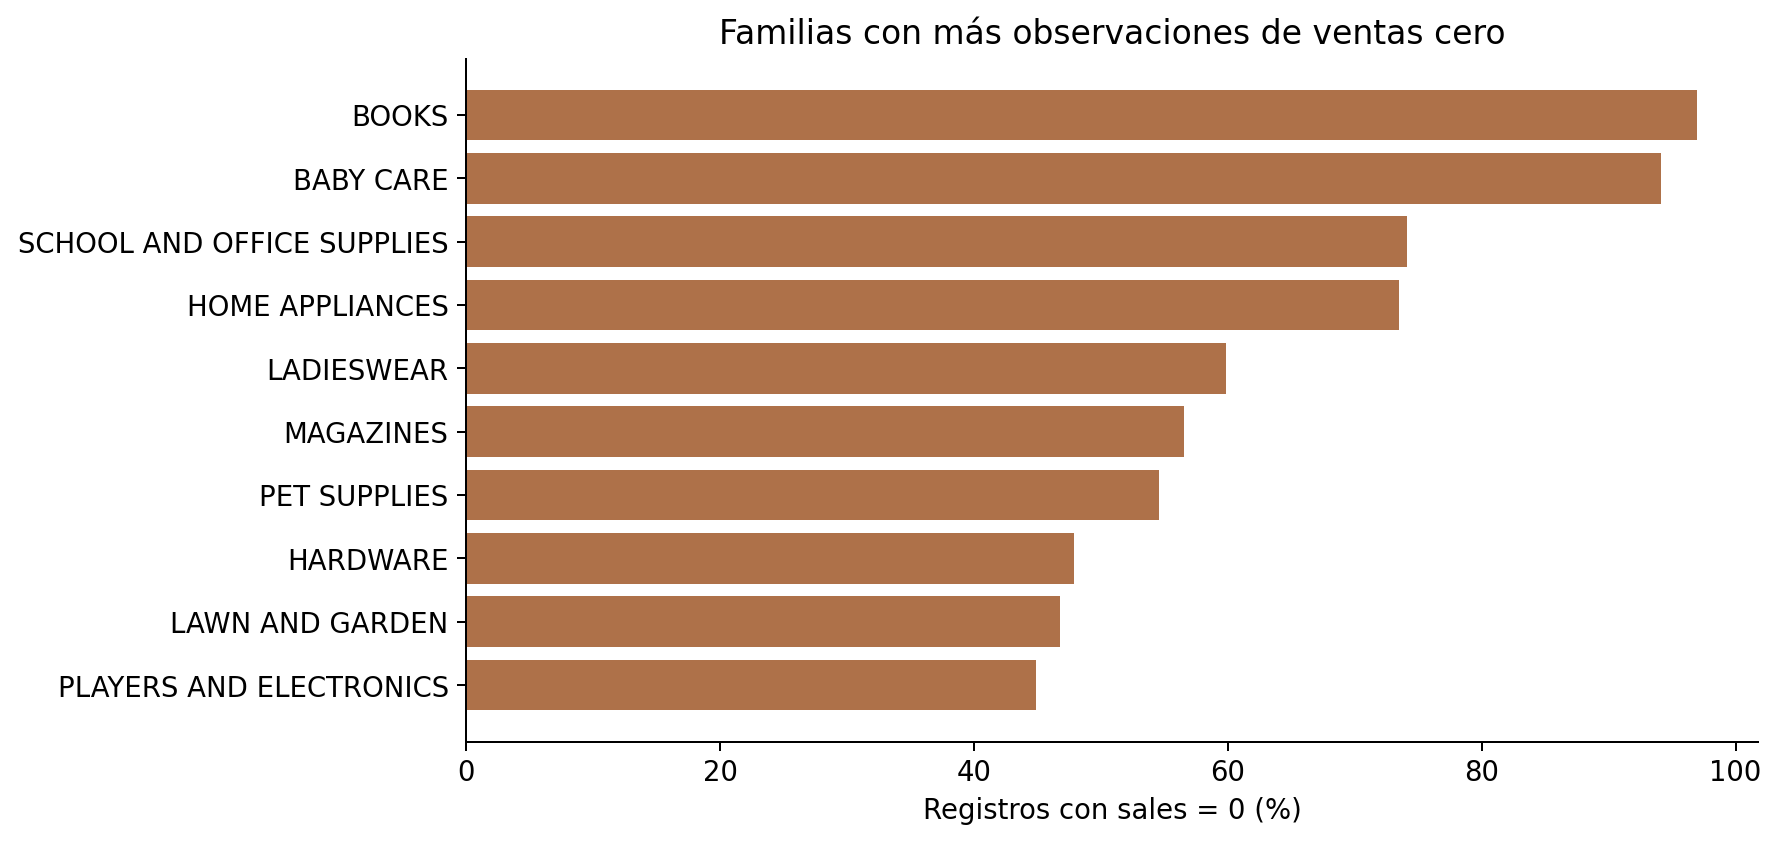

In [5]:
families = pd.read_csv(root / "outputs/eda/families.csv")
display(families.head(10).round(3))
display(Image(filename=str(root / "docs/figures/04_zero_sales.png")))

## Promociones

La siguiente tabla compara medias y tamaños de grupo por familia. Es una asociación descriptiva. Las promociones pueden coincidir con productos o fechas de mayor venta y esta comparación no demuestra causalidad.

In [6]:
promotion = pd.read_csv(root / "outputs/eda/promotion_by_family.csv")
display(promotion.loc[promotion["family"].isin(["GROCERY I", "PRODUCE", "DAIRY"])].round(2))

,family,is_promotion,mean,size
15,DAIRY,False,479.81,44951
16,DAIRY,True,933.34,45985
23,GROCERY I,False,2717.72,34050
24,GROCERY I,True,4411.00,56886
59,PRODUCE,False,792.10,60152
60,PRODUCE,True,2438.22,30784


## Decisiones para el modelado

Conservo los ceros y los valores altos. Uso calendario, metadatos, promociones y ventas anteriores. La evaluación se hace en bloques completos de 16 días. El forecast debe reutilizar sus propias predicciones cuando un retardo entra en ese bloque. Las comprobaciones de calidad y los joins están implementados en `src/data.py`.